## Bat Tracking Data

In [2]:
import pandas as pd
import numpy as np


def add_year_column(df, date_col='game_date'):
    """Convert date_col to datetime and add a 'year' column derived from it."""
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df['year'] = df[date_col].dt.year
    return df


def add_swing_column(df):
    """Flag pitches that were swung at, excluding automatic ball/strike calls."""
    swing_events = ['swinging_strike', 'foul', 'hit_into_play',
                     'swinging_strike_blocked', 'foul_tip', 'foul_bunt', 'bunt_foul_tip']
    df = df[~df['description'].isin(['automatic_ball', 'automatic_strike'])].copy()
    df['swing'] = df['description'].isin(swing_events).astype(int)
    return df


def add_pitch_category_column(df):
    """Bucket pitch_type into FB (fastballs), BB (breaking balls), OS (off-speed)."""
    FB = ['FF', 'FC', 'SI']
    BB = ['SL', 'CU', 'KC', 'ST', 'SV', 'EP']
    OS = ['CH', 'FS']
    df = df.copy()
    df['pitch_cat'] = np.select(
        [df['pitch_type'].isin(FB), df['pitch_type'].isin(BB), df['pitch_type'].isin(OS)],
        ['FB', 'BB', 'OS'],
        default='Other'
    )
    return df


def swing_percentage_by_year(df):
    """Swing % grouped by year."""
    return df.groupby('year')['swing'].mean() * 100


def hitting_metrics_by_year(df, value_order):
    """Mean hitting metrics grouped by year, in the given column order."""
    pivot = df.pivot_table(index='year', values=value_order, aggfunc='mean')
    return pivot[value_order]


def hitting_metrics_by_pitch_category(df, value_order, index_order=('FB', 'BB', 'OS')):
    """Mean hitting metrics grouped by pitch category and year."""
    pivot = df.pivot_table(index='pitch_cat', columns='year', values=value_order, aggfunc='mean')
    return pivot.reindex(index=list(index_order)).reindex(columns=value_order, level=0)


def top_n_metric_means(df, metric, value_order, n=10):
    """Return (mean of value_order columns, the rows themselves) for the top-n rows by metric."""
    df_top = df.nlargest(n, metric)
    return df_top[value_order].mean(), df_top

In [ ]:
df = pd.read_csv("../sample_data/zac_veen_bat_tracking.csv")
df.head(5)

In [4]:
df = add_year_column(df)

In [5]:
## Create swing column where if bat_speed is not null, then swing is 1, else 0
df = add_swing_column(df)

df['swing'].value_counts()

swing
1    170
0    111
Name: count, dtype: int64

In [6]:
# determine swing percentage by year
swing_percentage_by_year(df)

year
2025    62.142857
2026    58.865248
Name: swing, dtype: float64

In [7]:
# Create pitch type categories
df = add_pitch_category_column(df)

df['pitch_cat'].value_counts()

pitch_cat
FB    179
BB     58
OS     44
Name: count, dtype: int64

In [8]:
## Create pivot table for hitting metrics by year (all pitch types combined)

value_order = ['attack_direction',
               'attack_angle', 'launch_angle', 'launch_speed',
               'intercept_ball_minus_batter_pos_x_inches', 'intercept_ball_minus_batter_pos_y_inches',
               'bat_speed', 'swing_length', 'swing_path_tilt',
               'miss_distance']

## show the pivot table
hitting_metrics_by_year(df, value_order)

,attack_direction,attack_angle,launch_angle,launch_speed,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches,bat_speed,swing_length,swing_path_tilt,miss_distance
year,,,,,,,,,,
2025,9.039459,4.775697,22.317073,81.115000,38.394132,24.256718,66.244578,6.466265,29.004642,1.711445
2026,1.701893,12.455592,15.756757,84.075676,37.627311,35.125462,68.993590,6.898718,32.372849,2.483207


In [9]:
## Create pivot table for hitting metrics by year, split by pitch category

hitting_metrics_by_pitch_category(df, value_order)

attack_direction            attack_angle            launch_angle  \
year                  2025       2026         2025       2026         2025   
pitch_cat                                                                    
FB               17.257298  16.021697    -0.304489   3.794512        25.92   
BB               -8.884284 -13.000664    13.785401  24.784317        43.00   
OS               -9.044251 -21.679627    17.473288  22.245040         0.90   

                     launch_speed             \
year            2026         2025       2026   
pitch_cat                                      
FB         29.166667    77.028000  82.744444   
BB         -1.000000    81.066667  86.350000   
OS         10.000000    92.500000  83.600000   

          intercept_ball_minus_batter_pos_x_inches             \
year                                          2025       2026   
pitch_cat                                                       
FB                                       38.148323  36.482864   
BB                                       36.810726  38.652527   
OS                                       40.489369  39.685751   

          intercept_ball_minus_batter_pos_y_inches             bat_speed  \
year                                          2025       2026       2025   
pitch_cat                                                                  
FB                                       18.729023  26.599549  64.371930   
BB                                       35.853513  42.961777  68.327273   
OS                                       36.757645  50.208810  71.833333   

                     swing_length           swing_path_tilt             \
year            2026         2025      2026            2025       2026   
pitch_cat                                                                
FB         66.911364     5.952632  6.250000       27.233697  31.938284   
BB         68.752632     7.527273  7.668421       34.229966  31.735393   
OS         75.406667     7.640000  7.826667       31.902329  34.455017   

          miss_distance            
year               2025      2026  
pitch_cat                          
FB             1.110555  1.234071  
BB             5.596822  3.005714  
OS             3.003646  5.591765

In [10]:
## Grab the top 10 rows with highest estimated_slg_using_speedangle and
## determine average value metrics for that subset

value_order_top10 = ['attack_direction',
                      'attack_angle', 'launch_angle', 'launch_speed',
                      'intercept_ball_minus_batter_pos_x_inches', 'intercept_ball_minus_batter_pos_y_inches',
                      'bat_speed', 'swing_length', 'swing_path_tilt']

top10_means, df_top10 = top_n_metric_means(df, 'estimated_slg_using_speedangle', value_order_top10, n=10)

## show the result
top10_means

attack_direction                            -4.934393
attack_angle                                14.955685
launch_angle                                23.500000
launch_speed                                98.170000
intercept_ball_minus_batter_pos_x_inches    38.488374
intercept_ball_minus_batter_pos_y_inches    35.458920
bat_speed                                   74.277778
swing_length                                 7.422222
swing_path_tilt                             32.121301
dtype: float64

In [11]:
df_top10['year'].value_counts()

year
2026    7
2025    3
Name: count, dtype: int64

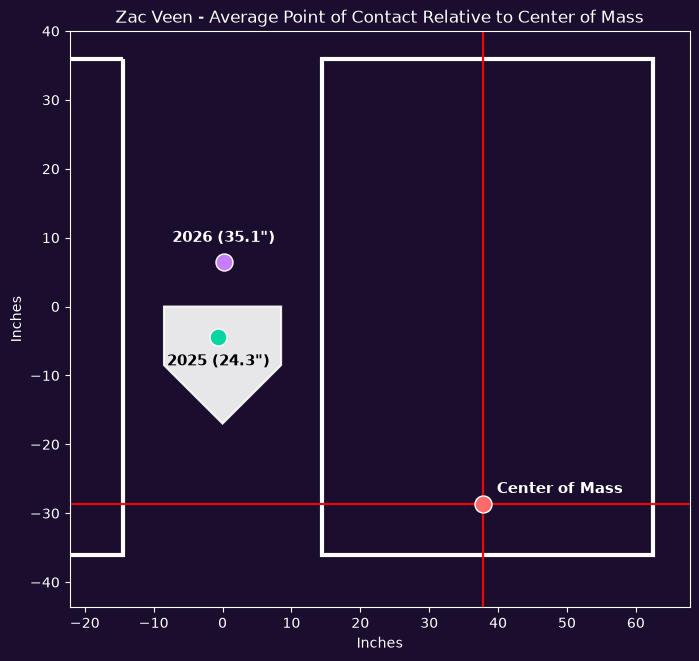

In [12]:
## Point of contact relative to home plate, by year

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np

def plot_point_of_contact(df, player_name):
    player_name = player_name

    # average point of contact by year
    intercept_x_2026 = df[df['year'] == 2026]['intercept_ball_minus_batter_pos_x_inches'].mean()
    intercept_y_2026 = df[df['year'] == 2026]['intercept_ball_minus_batter_pos_y_inches'].mean()
    intercept_x_2025 = df[df['year'] == 2025]['intercept_ball_minus_batter_pos_x_inches'].mean()
    intercept_y_2025 = df[df['year'] == 2025]['intercept_ball_minus_batter_pos_y_inches'].mean()

    # color scheme
    background_color = '#1A0D2E'
    low_ellipse_color = '#FF6B6B'
    below_ellipse_color = '#FFA552'
    above_ellipse_color = '#06D6A0'
    high_ellipse_color = '#C77DFF'

    # home plate geometry (standard MLB dimensions, inches)
    # front edge (facing pitcher) is 17" wide, centered on x=0, at y=0
    # two 8.5" sides run back to y=-8.5, then two 12" angled sides meet at the back tip
    half_width = 8.5
    side_length = 8.5
    back_tip_y = -(side_length + 12 * np.cos(np.radians(45)))  # ~ -17
    gap = 6
    half_side_box = 36
    top_box = 48

    plate_vertices = [
        (-half_width, 0),
        (half_width, 0),
        (half_width, -side_length),
        (0, back_tip_y),
        (-half_width, -side_length),
    ]

    l_box_vertices = [
        (half_width + gap, half_side_box),
        (half_width + gap + top_box, half_side_box),
        (half_width + gap + top_box, -half_side_box),
        (half_width + gap, -half_side_box)
    ]

    r_box_vertices = [
        (-half_width - gap, half_side_box),
        (-half_width - gap - top_box, half_side_box),
        (-half_width - gap - top_box, -half_side_box),
        (-half_width - gap, -half_side_box)
    ]

    # reference lines
    horizontal_line_y = back_tip_y - 11.7   # 11.7" behind the back tip of the plate
    vertical_line_x = half_width + 29.3     # 29.3" right of the plate's right edge

    # data points
    point_2026 = (
        vertical_line_x - intercept_x_2026,     # 37.6" left of the vertical line
        horizontal_line_y + intercept_y_2026,   # 35.1" above the horizontal line
    )
    point_2025 = (
        vertical_line_x - intercept_x_2025,     # 38.3" left of the vertical line
        horizontal_line_y + intercept_y_2025,   # 24.2" above the horizontal line
    )
    center_of_mass = (
        vertical_line_x,
        horizontal_line_y
    )

    # build the figure
    fig, ax = plt.subplots(figsize=(8, 8))
    fig.patch.set_facecolor(background_color)
    ax.set_facecolor(background_color)

    plate = Polygon(plate_vertices, closed=True, facecolor='white',
                    edgecolor='white', linewidth=1.5, alpha=0.9, zorder=2)
    ax.add_patch(plate)

    l_box = Polygon(l_box_vertices, closed=True, facecolor='none',
                    edgecolor='white', linewidth=3, zorder=1)
    ax.add_patch(l_box)

    r_box = Polygon(r_box_vertices, closed=True, facecolor='none',
                    edgecolor='white', linewidth=3, zorder=1)
    ax.add_patch(r_box)

    ax.axhline(horizontal_line_y, color='red', linewidth=1.5, zorder=1)
    ax.axvline(vertical_line_x, color='red', linewidth=1.5, zorder=1)

    ax.scatter(*point_2026, s=150, color=high_ellipse_color, edgecolor='white', zorder=3)
    ax.scatter(*point_2025, s=150, color=above_ellipse_color, edgecolor='white', zorder=3)
    ax.scatter(*center_of_mass, s=150, color=low_ellipse_color, edgecolor='white', zorder=3)

    ax.annotate(f'2026 ({intercept_y_2026:.1f}")', point_2026, textcoords='offset points',
                xytext=(0, 12), ha='center', va='bottom',
                color='white', fontsize=11, fontweight='bold')
    ax.annotate(f'2025 ({intercept_y_2025:.1f}")', point_2025, textcoords='offset points',
                xytext=(0, -12), ha='center', va='top',
                color="black", fontsize=11, fontweight='bold')
    ax.annotate('Center of Mass', center_of_mass, textcoords='offset points', xytext=(10, 8),
                color='white', fontsize=11, fontweight='bold')

    ax.set_xlim(vertical_line_x - 60, vertical_line_x + 30)
    ax.set_ylim(horizontal_line_y - 15, 40)
    ax.set_aspect('equal')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_color('white')

    ax.set_xlabel('Inches', color='white')
    ax.set_ylabel('Inches', color='white')
    ax.set_title(f'{player_name} - Average Point of Contact Relative to Center of Mass', color='white')

    plt.show()

plot_point_of_contact(df, "Zac Veen")

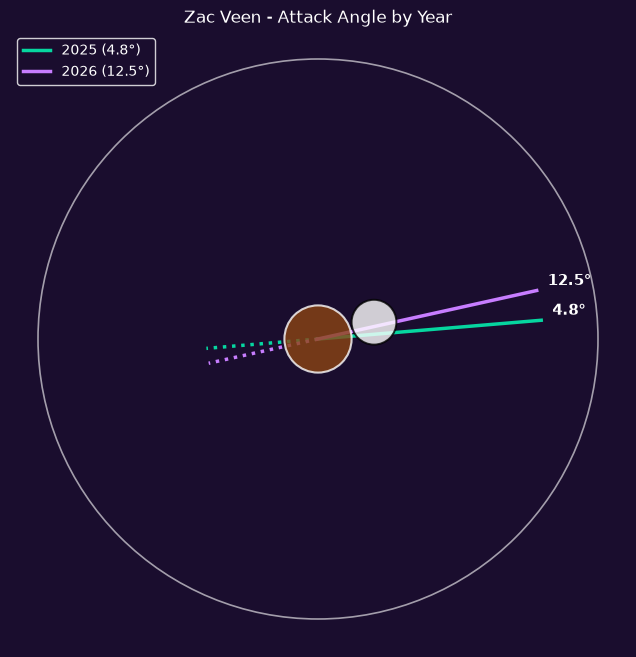

In [13]:
## Attack angle by year

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np

def plot_attack_angle_by_year(df, player_name):
        player_name = player_name

        # color scheme
        background_color = '#1A0D2E'
        low_ellipse_color = '#FF6B6B'
        below_ellipse_color = '#FFA552'
        above_ellipse_color = '#06D6A0'
        high_ellipse_color = '#C77DFF'
        bat_color = 'saddlebrown'
        ball_color = 'white'

        # gather attack angle data by year (rounded to 1 decimal place)
        angle_2026 = round(df[df['year'] == 2026]['attack_angle'].mean(), 1)
        angle_2025 = round(df[df['year'] == 2025]['attack_angle'].mean(), 1)

        vertex = (0, 0)          # point of contact
        bat_radius = 6
        ball_radius = 4
        line_length_right = 40   # follow-through, solid
        line_length_left = 20    # approach path, dotted, extends past the ball

        # bat and ball are tangent at the vertex (touching, not overlapping)
        bat_center = (vertex[0], vertex[1])
        ball_center = (vertex[0] + bat_radius + ball_radius, vertex[1]+3)

        def angle_point(origin, angle_deg, length):
                angle_rad = np.radians(angle_deg)
                return (origin[0] + length * np.cos(angle_rad), origin[1] + length * np.sin(angle_rad))

        def plot_swing_line(ax, angle_deg, color, label):
                right_end = angle_point(vertex, angle_deg, line_length_right)
                left_end = angle_point(vertex, angle_deg + 180, line_length_left)
                ax.plot([vertex[0], right_end[0]], [vertex[1], right_end[1]],
                        color=color, linewidth=2.5, zorder=2, label=label)
                ax.plot([vertex[0], left_end[0]], [vertex[1], left_end[1]],
                        color=color, linewidth=2.5, linestyle=':', zorder=2)
                ax.annotate(f'{angle_deg}°', right_end, textcoords='offset points', xytext=(8, 4),
                                color='white', fontsize=11, fontweight='bold')

        fig, ax = plt.subplots(figsize=(8, 8))
        fig.patch.set_facecolor(background_color)
        ax.set_facecolor(background_color)

        plot_swing_line(ax, angle_2025, above_ellipse_color, f'2025 ({angle_2025}°)')
        plot_swing_line(ax, angle_2026, high_ellipse_color, f'2026 ({angle_2026}°)')

        # bat (large, opaque brown circle)
        bat = Circle(bat_center, radius=bat_radius, facecolor=bat_color, alpha=0.8, edgecolor='white', linewidth=1.5, zorder=3)
        ax.add_patch(bat)

        # ball (slightly smaller white circle), bouncing off the bat rather than inside it
        ball = Circle(ball_center, radius=ball_radius, facecolor=ball_color, alpha=0.8, edgecolor='black', linewidth=1.4, zorder=4)
        ax.add_patch(ball)

        # circular axis boundary in place of a rectangular frame with inches
        axis_radius = line_length_right + 10
        boundary = Circle(vertex, radius=axis_radius, facecolor='none', edgecolor='white', linewidth=1.2, alpha=0.6, zorder=0)
        ax.add_patch(boundary)

        ax.set_xlim(vertex[0] - axis_radius - 5, vertex[0] + axis_radius + 5)
        ax.set_ylim(vertex[1] - axis_radius - 5, vertex[1] + axis_radius + 5)
        ax.set_aspect('equal')
        ax.axis('off')

        ax.set_title(f'{player_name} - Attack Angle by Year', color='white')
        ax.legend(facecolor=background_color, edgecolor='white', labelcolor='white', loc='upper left')

        plt.show()

plot_attack_angle_by_year(df, "Zac Veen")

## Statcast Data

### Helper Functions

In [14]:
import pandas as pd
import numpy as np


def add_year_column(df, date_col='game_date'):
    """Convert date_col to datetime and add a 'year' column derived from it."""
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df['year'] = df[date_col].dt.year
    return df


def add_swing_column(df):
    """Flag pitches that were swung at, excluding automatic ball/strike calls."""
    swing_events = ['swinging_strike', 'foul', 'hit_into_play',
                     'swinging_strike_blocked', 'foul_tip', 'foul_bunt', 'bunt_foul_tip']
    df = df[~df['description'].isin(['automatic_ball', 'automatic_strike'])].copy()
    df['swing'] = df['description'].isin(swing_events).astype(int)
    return df


def add_swing_and_miss_column(df):
    """Flag swings that resulted in a miss."""
    df = df.copy()
    df['swing_and_miss'] = df['description'].isin(
        ['swinging_strike', 'swinging_strike_blocked', 'foul_tip', 'bunt_foul_tip']
    ).astype(int)
    return df


def add_pitch_category_column(df):
    """Bucket pitch_type into FB (fastballs), BB (breaking balls), OS (off-speed)."""
    FB = ['FF', 'FC', 'SI']
    BB = ['SL', 'CU', 'KC', 'ST', 'SV', 'EP']
    OS = ['CH', 'FS']
    df = df.copy()
    df['pitch_cat'] = np.select(
        [df['pitch_type'].isin(FB), df['pitch_type'].isin(BB), df['pitch_type'].isin(OS)],
        ['FB', 'BB', 'OS'],
        default='Other'
    )
    return df


def add_in_zone_column(df):
    """Flag pitches thrown in the strike zone (Statcast zones 1-9)."""
    in_zone_values = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
    df = df.copy()
    df['in_zone'] = df['zone'].isin(in_zone_values).astype(int)
    return df


def swing_percentage_by_year(df):
    """Swing % grouped by year."""
    return df.groupby('year')['swing'].mean() * 100


def swing_and_miss_percentage_by_year(df):
    """Whiff % (of swings) grouped by year."""
    df_swings = df[df['swing'] == 1]
    return df_swings.groupby('year')['swing_and_miss'].mean() * 100


def swing_percentage_by_pitch_category(df):
    """Swing % grouped by year and pitch category."""
    return df.groupby(['year', 'pitch_cat'])['swing'].mean() * 100


def swing_and_miss_percentage_by_pitch_category(df):
    """Whiff % (of swings) grouped by year and pitch category."""
    df_swings = df[df['swing'] == 1]
    return df_swings.groupby(['year', 'pitch_cat'])['swing_and_miss'].mean() * 100


def total_pitches_by_pitch_category(df):
    """Pitch counts grouped by year and pitch category."""
    return df.groupby(['year', 'pitch_cat']).size()


def swing_percentage_by_zone(df):
    """Swing % grouped by zone location, pitch category, and year."""
    return df.groupby(['in_zone', 'pitch_cat', 'year'])['swing'].mean() * 100


def swing_and_miss_percentage_by_zone(df):
    """Whiff % (of swings) grouped by zone location, pitch category, and year."""
    df_swings = df[df['swing'] == 1]
    return df_swings.groupby(['in_zone', 'pitch_cat', 'year'])['swing_and_miss'].mean() * 100

In [ ]:
## Read in the CSV file
df_sc = pd.read_csv("../sample_data/zac_veen_2025_2026.csv")

# only take regular season
df_sc = df_sc[df_sc['game_type'] == 'R']

# head
df_sc.head()

In [16]:
df_sc['description'].value_counts()

description
ball                       90
swinging_strike            68
foul                       50
hit_into_play              39
called_strike              17
foul_tip                    6
foul_bunt                   4
hit_by_pitch                2
blocked_ball                2
swinging_strike_blocked     2
bunt_foul_tip               1
automatic_ball              1
Name: count, dtype: int64

In [17]:
## create swing column

df_sc = add_swing_column(df_sc)

df_sc['swing'].value_counts()

swing
1    170
0    111
Name: count, dtype: int64

In [18]:
# create swing and miss column

df_sc = add_swing_and_miss_column(df_sc)

df_sc['swing_and_miss'].value_counts()

swing_and_miss
0    204
1     77
Name: count, dtype: int64

In [19]:
df_sc = add_year_column(df_sc)

In [20]:
## Determine swing percentage by year

swing_percentage_by_year(df_sc)

year
2025    62.142857
2026    58.865248
Name: swing, dtype: float64

In [21]:
# Determine swing and miss percentage by year

swing_and_miss_percentage_by_year(df_sc)

year
2025    43.678161
2026    46.987952
Name: swing_and_miss, dtype: float64

In [22]:
df_sc['pitch_type'].value_counts()

pitch_type
FF    114
SI     36
FC     29
CH     26
SL     22
FS     18
ST     18
CU     13
KC      4
EP      1
Name: count, dtype: int64

In [23]:
## Determine Whiff by pitch type

df_sc = add_pitch_category_column(df_sc)

df_sc['pitch_cat'].value_counts()

pitch_cat
FB    179
BB     58
OS     44
Name: count, dtype: int64

In [24]:
# Whiff rates by catagory by year
swing_and_miss_percentage_by_pitch_category(df_sc)

year  pitch_cat
2025  BB           36.363636
      FB           49.180328
      OS           26.666667
2026  BB           28.571429
      FB           53.191489
      OS           53.333333
Name: swing_and_miss, dtype: float64

Swing and miss rates remain pretty much the same

In [25]:
## Swing percentage by pitch category by year

swing_percentage_by_pitch_category(df_sc)

year  pitch_cat
2025  BB           44.000000
      FB           62.244898
      OS           88.235294
2026  BB           63.636364
      FB           58.024691
      OS           55.555556
Name: swing, dtype: float64

| Pitch Category | 2025 | 2026 |
|-----------------|------|------|
| Breaking Balls | 44.0% | 63.6% |
| Fast Balls | 62.2% | 58.0% |
| Off-Speed | 88.2% | 55.6% |

Swing rates are down except for BB - Possibly small numbers

In [26]:
# Total pitches by pitch category by year
total_pitches_by_pitch_category(df_sc)

year  pitch_cat
2025  BB           25
      FB           98
      OS           17
2026  BB           33
      FB           81
      OS           27
dtype: int64

In [27]:
## in zone or out of zone

df_sc = add_in_zone_column(df_sc)

df_sc['in_zone'].value_counts()

in_zone
0    148
1    133
Name: count, dtype: int64

In [28]:
## Swing percentage by zone location

swing_percentage_by_zone(df_sc)

in_zone  pitch_cat  year
0        BB         2025     26.666667
                    2026     52.380952
         FB         2025     29.545455
                    2026     37.777778
         OS         2025     66.666667
                    2026     35.294118
1        BB         2025     70.000000
                    2026     83.333333
         FB         2025     88.888889
                    2026     83.333333
         OS         2025    100.000000
                    2026     90.000000
Name: swing, dtype: float64

In [29]:
swing_and_miss_percentage_by_zone(df_sc)

in_zone  pitch_cat  year
0        BB         2025    50.000000
                    2026    54.545455
         FB         2025    76.923077
                    2026    64.705882
         OS         2025    50.000000
                    2026    50.000000
1        BB         2025    28.571429
                    2026     0.000000
         FB         2025    41.666667
                    2026    46.666667
         OS         2025    18.181818
                    2026    55.555556
Name: swing_and_miss, dtype: float64

| Pitch Category | In Zone | 2025 | 2026 |
|-----------------|---------|------|------|
| Breaking Balls | Out-of-Zone | 50.0% | 54.5% |
| Breaking Balls | In-Zone | 28.6% | 0.0% |
| Fast Balls | Out-of-Zone | 76.9% | 64.7% |
| Fast Balls | In-Zone | 41.7% | 46.7% |
| Off-Speed | Out-of-Zone | 50.0% | 50.0% |
| Off-Speed | In-Zone | 18.2% | 55.6% |

| Zone | 2025 | 2026 |
|---------|------|------|
| Out-of-Zone | 26.7% | 52.4% |
| In-Zone | 70.0% | 83.3% |

| Zone | 2025 | 2026 |
|---------|------|------|
| Out-of-Zone | 50.0% | 54.5% |
| In-Zone | 28.6% | 0.0% |